# E4 — Quus and the teachable rule (rule-following + interpretability)

*A working demonstration of Beetle-Box experiment **E4**. Full write-up:
[`docs/e4_quus.md`](../docs/e4_quus.md).*

**Kripke's quus.** The operator `a quus b` equals `a + b` for every pair below a
bend-point `k`, and something else above it. If all your evidence is below the
bend, nothing in it settles whether you follow *plus* or *quus* (or infinitely
many other rules). "Memorizing" and "grasping the rule" are indistinguishable on
the data seen — the skeptical point.

E4 has two layers, and the payload is the **gap between them**:
1. **Behavioral** — train students only below the bend; read out what they
   extrapolate above it. Do they converge (a shared prior resolving the
   underdetermination) or diverge (underdetermination made visible)?
2. **Mechanistic** — grok modular addition in a from-scratch transformer, read out
   the learned circuit, and ask whether two models on identical data implement the
   *same* algorithm.

## 1. Behavioral layer — which rule gets extrapolated?

Several seeded students are trained only on below-bend pairs (where plus = quus),
then asked about above-bend pairs (where they disagree). The **operand encoding**
decides whether a shared prior can reach across the bend: `scalar` (operands are
values → simplicity prior can extend plus) vs `onehot` (each value independent →
above-bend outputs unconstrained).

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from beetlebox.config import E4RunConfig, E4ExperimentConfig, QuusConfig, RuleLearnerConfig
from beetlebox.harness import E4RunManager
from beetlebox.analysis import e4

warnings.filterwarnings("ignore")
OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73", "vermil": "#D55E00"}
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold", "font.size": 10})

def behav(encoding, num_seeds=8, steps=4000):
    cfg = E4RunConfig(seed=0)
    cfg.experiment = E4ExperimentConfig(num_seeds=num_seeds)
    cfg.quus = QuusConfig(max_operand=12, bend=8, modulus=24, quus_value=0, encoding=encoding)
    cfg.learner = RuleLearnerConfig(num_steps=steps)
    s = E4RunManager(cfg).run()
    plus = s["plus"]
    plus_rate = e4._rate(s["predictions"], plus)
    agree = e4.cross_seed_agreement(s["predictions"])
    return plus_rate, agree

rows = {enc: behav(enc) for enc in ("scalar", "onehot")}
for enc, (pr, ag) in rows.items():
    print(f"{enc:7s} plus_rate={pr:.3f}  cross_seed_agreement={ag:.3f}")

scalar  plus_rate=0.734  cross_seed_agreement=0.625
onehot  plus_rate=0.000  cross_seed_agreement=0.212


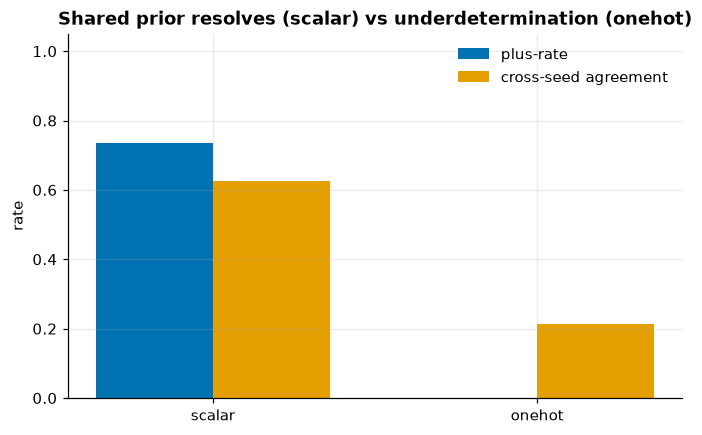

In [2]:
encs = ["scalar", "onehot"]
plus = [rows[e][0] for e in encs]; agree = [rows[e][1] for e in encs]
x = np.arange(len(encs)); w = 0.36
fig, ax = plt.subplots()
ax.bar(x - w/2, plus, w, color=OKABE["blue"], label="plus-rate")
ax.bar(x + w/2, agree, w, color=OKABE["orange"], label="cross-seed agreement")
ax.set_xticks(x); ax.set_xticklabels(encs); ax.set_ylim(0, 1.05); ax.set_ylabel("rate")
ax.set_title("Shared prior resolves (scalar) vs underdetermination (onehot)")
ax.legend(frameon=False, loc="upper right"); plt.show()

- **scalar**: students extrapolate *plus* most of the time and largely agree — a
  shared inductive prior (simplicity, over representable operands) quietly resolves
  the underdetermination.
- **onehot**: students recover neither plus nor each other — the underdetermination
  is unresolved and visible.

Neither *settles* which rule is "correct." Convergence just means a shared prior
picked one of the infinitely many rules the data allows. In **rich mode** a
frontier model — arithmetic as an inherited form of life — extrapolates plus at
≈1.0 (not run here; one API call per query).

## 2. Mechanistic layer — is the algorithm determinate?

Train a from-scratch transformer on `(a + b) mod p` with weight decay: it
**groks** — memorizes first, generalizes much later — then implements addition
with a sparse **Fourier circuit**. A full grok is ~25k steps (see the
[exemplary run](../results/exemplary/e4_quus/)); here we run a **short partial
grok** just to exercise the machinery and read a circuit out.

after 1500 steps (partial): train=1.00 val=0.55  (a full grok needs many more steps)


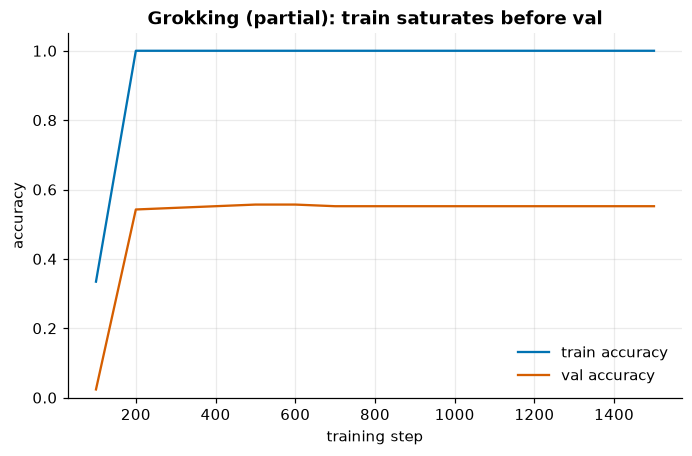

In [3]:
from beetlebox.config import GrokkingConfig
from beetlebox.mech.grokking import GrokkingRun
from beetlebox.mech import circuits

cfg = GrokkingConfig(modulus=23, d_model=64, n_heads=4, num_steps=1500,
                     eval_every=100, weight_decay=1.0, batch_size=0, train_frac=0.6, seed=0)
run = GrokkingRun(cfg)
s = run.run()
h = s["history"]
print(f"after {cfg.num_steps} steps (partial): train={s['final_train_acc']:.2f} "
      f"val={s['final_val_acc']:.2f}  (a full grok needs many more steps)")

fig, ax = plt.subplots()
steps = [r["step"] for r in h]
ax.plot(steps, [r["train_acc"] for r in h], color=OKABE["blue"], label="train accuracy")
ax.plot(steps, [r["val_acc"] for r in h], color=OKABE["vermil"], label="val accuracy")
ax.set_xlabel("training step"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.05)
ax.set_title("Grokking (partial): train saturates before val"); ax.legend(frameon=False)
plt.show()

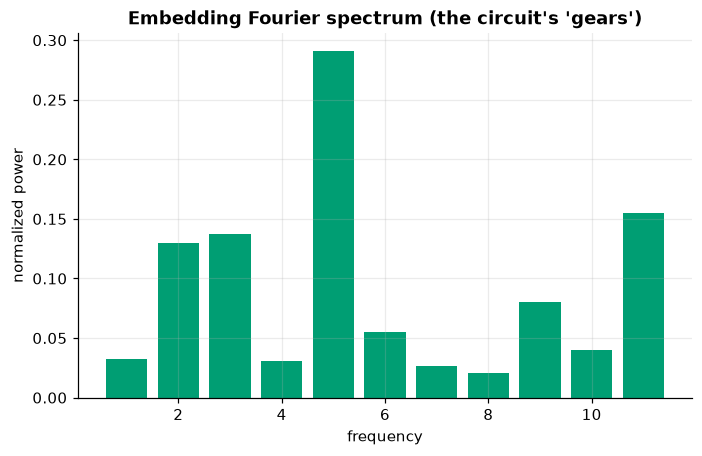

key frequencies: [5, 11, 3, 2, 9]
power concentration (top 5): 0.794


In [4]:
# Read the learned Fourier structure out of the embedding weights.
ps = circuits.fourier_power_spectrum(run.model)
fig, ax = plt.subplots()
ax.bar(range(1, len(ps) + 1), ps, color=OKABE["green"])
ax.set_xlabel("frequency"); ax.set_ylabel("normalized power")
ax.set_title("Embedding Fourier spectrum (the circuit's 'gears')"); plt.show()
print("key frequencies:", circuits.key_frequencies(run.model, top_k=5))
print("power concentration (top 5):", round(circuits.concentration(run.model, top_k=5), 3))

Even in a partial grok the embedding concentrates power in a few frequencies. The
[exemplary run](../results/exemplary/e4_quus/) trains two seeds to a full grok and
measures their **cross-seed algorithmic agreement** — the overlap of their
key-frequency sets. It is well below 1.0: two models on *identical* data implement
*different* algorithms ("The Clock and the Pizza").

## What E4 does (and does not) license

E4 does **not** resolve Kripke's skepticism. Behaviorally, convergence toward plus
is a shared prior selecting one rule, not an independent criterion (a longer finite
fact). Mechanistically, opening the box does not dissolve the skepticism either —
the circuit is itself a longer finite fact, and two models needn't even agree on
which circuit. The payload is exactly that **gap between behavioral
underdetermination and mechanistic (non-)determinacy**, relocated onto examinable
ground. (`plan/beetle-box.md` §4.4)

See the [approach doc](../docs/e4_quus.md) and the
[exemplary run](../results/exemplary/e4_quus/).